# Module A Report: Lightweight DBMS with B+ Tree Index

## Introduction
This notebook documents the B+ Tree implementation, benchmarking against a brute-force baseline, and Graphviz visualization outputs.

In [2]:
from database import BPlusTree, PerformanceAnalyzer
import pandas as pd
import matplotlib.pyplot as plt

## Implementation Details
Core methods implemented in `database/bplustree.py` include insertion, deletion with rebalance, exact search, update, range query, and visualization.

In [3]:
tree = BPlusTree(order=4)
for key in [10, 20, 5, 6, 12, 30, 7, 17]:
    tree.insert(key, {'id': key, 'score': key * 10})

print('search(12):', tree.search(12))
print('range_query(6, 17):', tree.range_query(6, 17))
tree.delete(6)
print('after delete(6), get_all():', tree.get_all())

search(12): {'id': 12, 'score': 120}
range_query(6, 17): [(6, {'id': 6, 'score': 60}), (7, {'id': 7, 'score': 70}), (10, {'id': 10, 'score': 100}), (12, {'id': 12, 'score': 120}), (17, {'id': 17, 'score': 170})]
after delete(6), get_all(): [(5, {'id': 5, 'score': 50}), (7, {'id': 7, 'score': 70}), (10, {'id': 10, 'score': 100}), (12, {'id': 12, 'score': 120}), (17, {'id': 17, 'score': 170}), (20, {'id': 20, 'score': 200}), (30, {'id': 30, 'score': 300})]


## Performance Analysis
Benchmark B+ Tree vs BruteForceDB for insert/search/delete/range query and memory usage.

In [4]:
analyzer = PerformanceAnalyzer(order=16, seed=42)
results = analyzer.run(sizes=[100, 1000, 5000], searches=200, deletes=100, ranges=100)
df = pd.DataFrame(analyzer.to_rows(results))
df

,size,structure,insert_time_ms,search_time_ms,delete_time_ms,range_time_ms,peak_memory_kb
0,100,BPlusTree,3.215083,0.114042,11.958208,4.004708,32.873047
1,100,BruteForceDB,0.243750,0.155083,0.171458,0.936125,12.351562
2,1000,BPlusTree,49.422125,0.105292,18.530458,7.394292,313.048828
3,1000,BruteForceDB,71.072916,2.410333,5.948458,6.894000,278.940430
4,5000,BPlusTree,1061.947208,0.133541,106.652750,50.620959,1705.156250
5,5000,BruteForceDB,2750.286583,11.644209,57.989083,69.104875,1633.359375


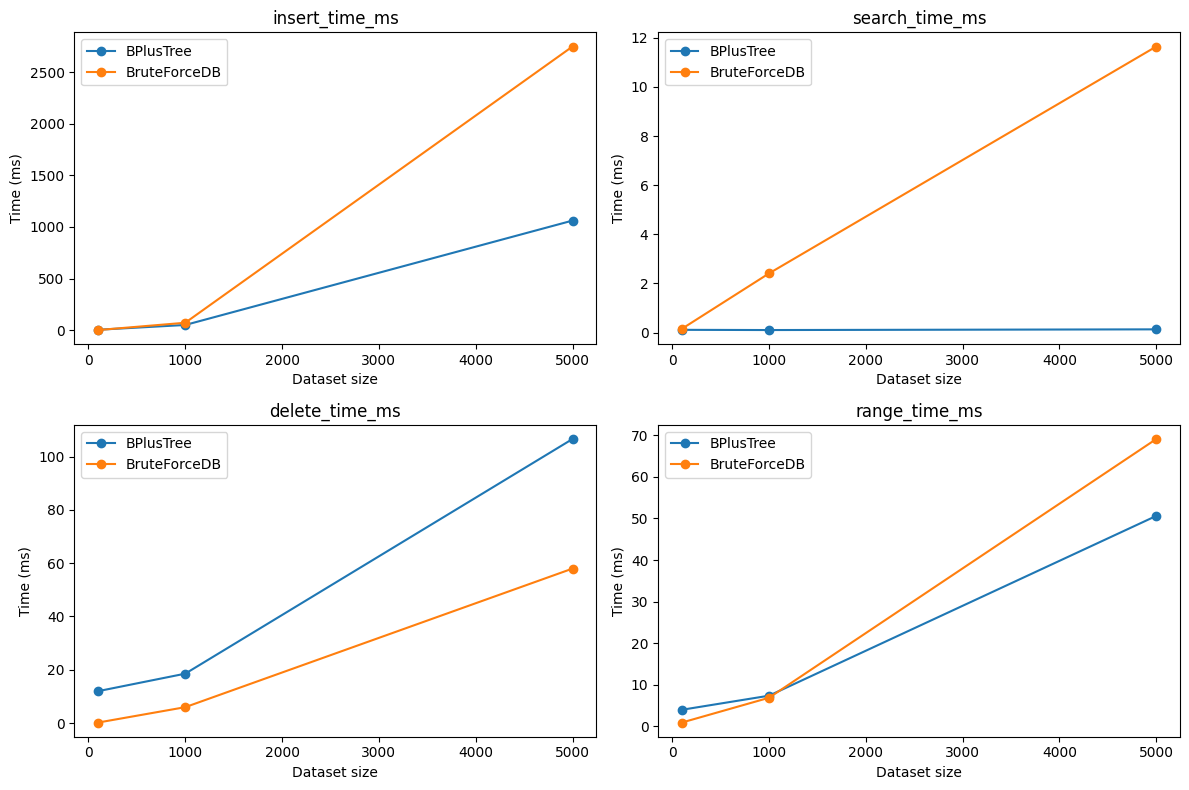

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ['insert_time_ms', 'search_time_ms', 'delete_time_ms', 'range_time_ms']
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    for structure in df['structure'].unique():
        sub = df[df['structure'] == structure]
        ax.plot(sub['size'], sub[metric], marker='o', label=structure)
    ax.set_title(metric)
    ax.set_xlabel('Dataset size')
    ax.set_ylabel('Time (ms)')
    ax.legend()

plt.tight_layout()
plt.show()

## Tree Visualization
Use Graphviz to render and inspect B+ Tree structure and leaf linkage.

In [6]:
import importlib
import database.bplustree as bpt_mod

# Reload module so notebook uses latest visualization fix from disk.
importlib.reload(bpt_mod)
BPlusTree = bpt_mod.BPlusTree
print('Using BPlusTree from:', bpt_mod.__file__)

Using BPlusTree from: /Users/umangshikarvar/Desktop/Module A/Multi-Course-Attendance-Management-Portal/Module-A/database/bplustree.py


Starting B+ Tree Visual Tests...

Test 1: Random Insertion
Insertion order: [9, 1, 5, 4, 6, 7, 8, 2, 3, 0]

Inserting 9


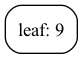


Inserting 1


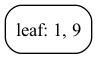


Inserting 5


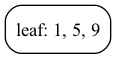


Inserting 4


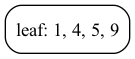


Inserting 6


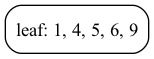


Inserting 7


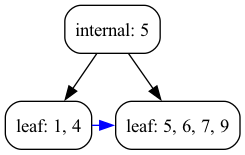


Inserting 8


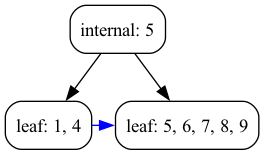


Inserting 2


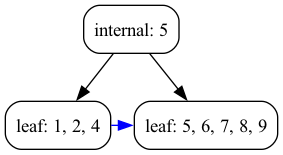


Inserting 3


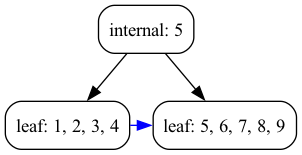


Inserting 0


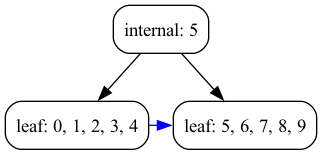


Test 2: Exact Search

Searching 4
Result: {'id': 4, 'value': 400}


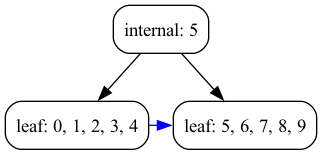


Searching 3
Result: {'id': 3, 'value': 300}


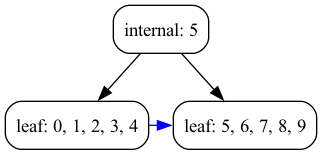


Searching 2
Result: {'id': 2, 'value': 200}


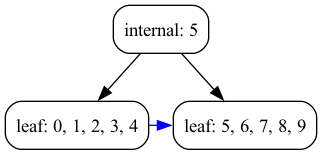


Test 3: Range Query

Range Query [2, 6]
Result: [(2, {'id': 2, 'value': 200}), (3, {'id': 3, 'value': 300}), (4, {'id': 4, 'value': 400}), (5, {'id': 5, 'value': 500}), (6, {'id': 6, 'value': 600})]


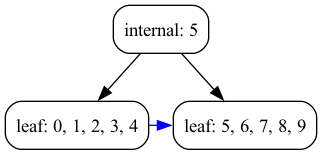


Test 4: Random Deletion
Deletion order: [0, 9, 3, 6, 1, 2, 7, 5, 4, 8]

Deleting 0


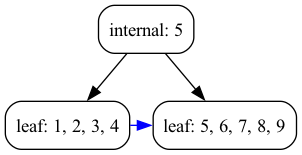


Deleting 9


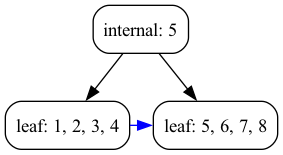


Deleting 3


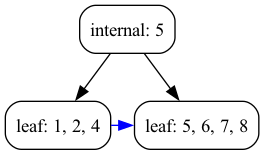


Deleting 6


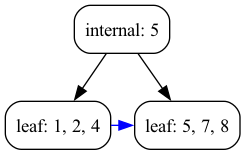


Deleting 1


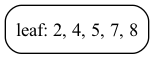


Visual Test Completed!


In [17]:
from IPython.display import Image, display
import os
import random

def show_tree(tree, step_name):
    filename = f"bplustree_{step_name}"
    images_dir = "demo_images"
    os.makedirs(images_dir, exist_ok=True)

    output_base = os.path.join(images_dir, filename)
    tree.visualize_tree(output_path=output_base, view=False)

    image_path = output_base + ".png"
    if os.path.exists(image_path):
        display(Image(filename=image_path))
    else:
        print(f"Image not generated for {step_name}")

def test_bplustree_visual():
    print("Starting B+ Tree Visual Tests...\n")

    tree = BPlusTree(order=6) # for internal node min_children=3, max_children=6, min_keys=2, max_keys=5 and leaf node min_keys=3, max_keys=6

    # -----------------------------
    # 1. RANDOM INSERTION
    # -----------------------------
    print("Test 1: Random Insertion")

    keys = list(range(10))
    random.shuffle(keys)

    print("Insertion order:", keys)

    for key in keys:
        print(f"\nInserting {key}")
        tree.insert(key, {"id": key, "value": key * 100})
        show_tree(tree, f"insert_{key}")

    # -----------------------------
    # 2. EXACT SEARCH
    # -----------------------------
    print("\nTest 2: Exact Search")

    search_keys = random.sample(keys, 3)

    for key in search_keys:
        print(f"\nSearching {key}")
        result = tree.search(key)
        print("Result:", result)
        show_tree(tree, f"search_{key}")

    # -----------------------------
    # 3. RANGE QUERY
    # -----------------------------
    print("\nTest 3: Range Query")

    l, r = sorted(random.sample(keys, 2))
    print(f"\nRange Query [{l}, {r}]")

    result = tree.range_query(l, r)
    print("Result:", result)
    show_tree(tree, f"range_{l}_{r}")

    # -----------------------------
    # 4. RANDOM DELETION
    # -----------------------------
    print("\nTest 4: Random Deletion")

    delete_keys = keys.copy()
    random.shuffle(delete_keys)

    print("Deletion order:", delete_keys)

    for key in delete_keys[:5]:  # delete some, not all
        print(f"\nDeleting {key}")
        tree.delete(key)
        show_tree(tree, f"delete_{key}")

    print("\nVisual Test Completed!")


# Run
test_bplustree_visual()

## Conclusion
Summarize complexity findings, implementation challenges, and future improvements here.

Add your video demo link in this section before final submission.